In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import openpyxl

# Läs in datasetet
df = pd.read_excel("hr_employee_data.xlsx")

df

,Emp_Id,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,IND02438,0.38,0.53,2,157,3,0,1,0,sales,low
1,IND28133,0.80,0.86,5,262,6,0,1,0,sales,medium
2,IND07164,0.11,0.88,7,272,4,0,1,0,sales,medium
3,IND30478,0.72,0.87,5,223,5,0,1,0,sales,low
4,IND24003,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...,...
14994,IND40221,0.40,0.57,2,151,3,0,1,0,support,low
14995,IND24196,0.37,0.48,2,160,3,0,1,0,support,low
14996,IND33544,0.37,0.53,2,143,3,0,1,0,support,low
14997,IND40533,0.11,0.96,6,280,4,0,1,0,support,low


     Emp_Id  satisfaction_level  last_evaluation  number_project  \
0  IND02438                0.38             0.53               2   
1  IND28133                0.80             0.86               5   
2  IND07164                0.11             0.88               7   
3  IND30478                0.72             0.87               5   
4  IND24003                0.37             0.52               2   

   average_montly_hours  time_spend_company  Work_accident  left  \
0                   157                   3              0     1   
1                   262                   6              0     1   
2                   272                   4              0     1   
3                   223                   5              0     1   
4                   159                   3              0     1   

   promotion_last_5years Department  salary  
0                      0      sales     low  
1                      0      sales  medium  
2                      0      sales  medium 

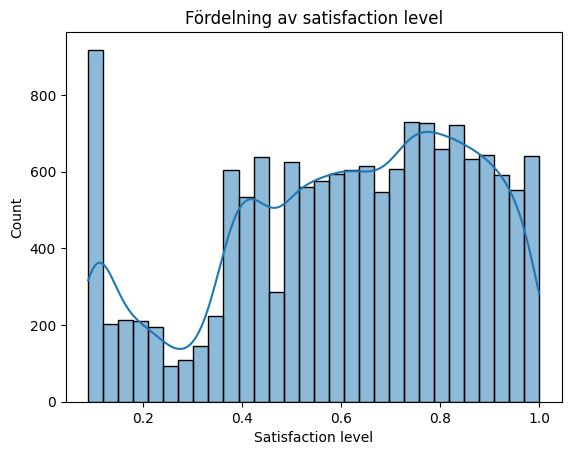

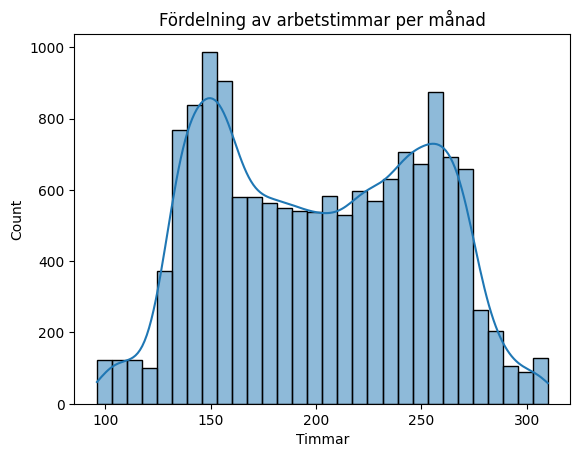

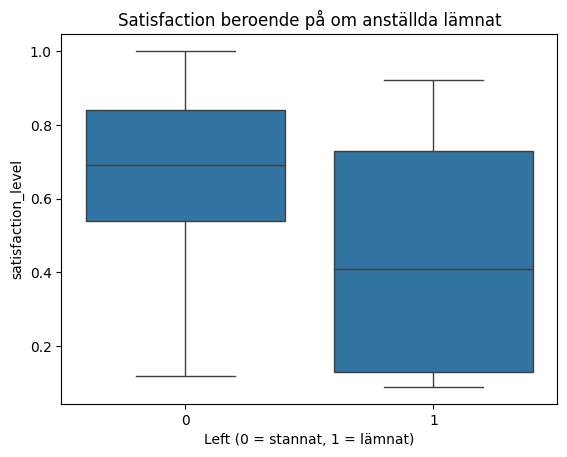

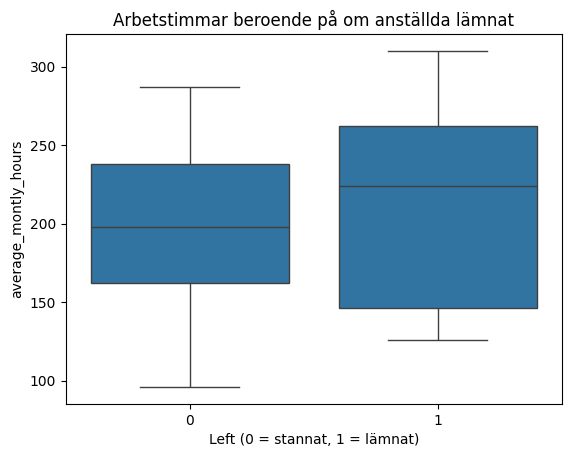

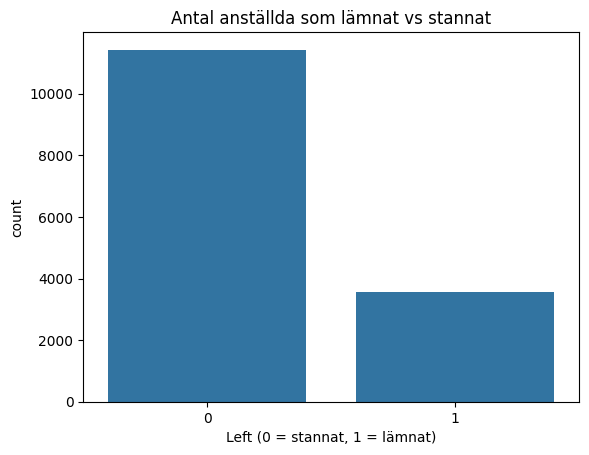

In [30]:


# Kontrollera att datan lästs in korrekt
print(df.head())
print(df.info())

# -----------------------------
# Fördelningar
# -----------------------------

# Satisfaction level
sns.histplot(df["satisfaction_level"], kde=True)
plt.title("Fördelning av satisfaction level")
plt.xlabel("Satisfaction level")
plt.show()

# Arbetstimmar per månad
sns.histplot(df["average_montly_hours"], kde=True)
plt.title("Fördelning av arbetstimmar per månad")
plt.xlabel("Timmar")
plt.show()

# -----------------------------
# Jämförelser
# -----------------------------

# Satisfaction vs left
sns.boxplot(x="left", y="satisfaction_level", data=df)
plt.title("Satisfaction beroende på om anställda lämnat")
plt.xlabel("Left (0 = stannat, 1 = lämnat)")
plt.show()

# Arbetstimmar vs left
sns.boxplot(x="left", y="average_montly_hours", data=df)
plt.title("Arbetstimmar beroende på om anställda lämnat")
plt.xlabel("Left (0 = stannat, 1 = lämnat)")
plt.show()

# -----------------------------
# Antal som lämnat/stannat
# -----------------------------

sns.countplot(x="left", data=df)
plt.title("Antal anställda som lämnat vs stannat")
plt.xlabel("Left (0 = stannat, 1 = lämnat)")
plt.show()

In [3]:
14#
# a) Läs in data
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Ladda data
X, y = load_diabetes(return_X_y=True, as_frame=True)

# b) Dela upp i train och test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# c) Träna två modeller
linreg = LinearRegression()
rf = RandomForestRegressor(random_state=42)

linreg.fit(X_train, y_train)
rf.fit(X_train, y_train)

# d) Utvärdera modeller
y_pred_linreg = linreg.predict(X_test)
y_pred_rf = rf.predict(X_test)

rmse_linreg = np.sqrt(mean_squared_error(y_test, y_pred_linreg))
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("RMSE LinearRegression:", rmse_linreg)
print("RMSE RandomForest:", rmse_rf)

# e) Välj bästa modell
if rmse_linreg < rmse_rf:
    best_model = linreg
    print("Bästa modell: LinearRegression")
else:
    best_model = rf
    print("Bästa modell: RandomForest")

RMSE LinearRegression: 53.85344583676592
RMSE RandomForest: 54.332408273184846
Bästa modell: LinearRegression


In [44]:
##15a
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Läs in dataset (obs: separator ;)
df = pd.read_csv("car_price_dataset.csv", sep=";")

# Rensa kolumnnamn
df.columns = df.columns.str.strip()

# Ta bort rader med saknade värden
df = df.dropna()

# Omvandla text till siffror
df = pd.get_dummies(df, drop_first=True)

# Målvariabel (det vi vill förutsäga)
y = df["Price"]

# Övriga variabler
X = df.drop("Price", axis=1)

# Dela upp data i träning och test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Skapa och träna modellen
modell = LinearRegression()
modell.fit(X_train, y_train)

# Testa modellen
noggrannhet = modell.score(X_test, y_test)

print("Modellens noggrannhet:", noggrannhet)
import joblib
joblib.dump(model, "car_price_model.joblib")

Modellens noggrannhet: 0.9991734731522042


['car_price_model.joblib']

In [ ]:
##15b
import streamlit as st
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

df = pd.read_csv("car_price_dataset.csv", sep=";")

st.title("Bilpris prediktion")

X = df.drop("Price", axis=1)
y = df["Price"]

X_encoded = pd.get_dummies(X)

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2)
model = LinearRegression()
model.fit(X_train, y_train)

st.write("Fyll i några enkla uppgifter")

# -------- INPUT -------- #

year = st.number_input("År", value=2015)
engine = st.number_input("Motorstorlek", value=2.0)
mileage = st.number_input("Körsträcka", value=100000)
doors = st.number_input("Antal dörrar", value=4)
owners = st.number_input("Antal tidigare ägare", value=1)

input_data = {
    "Year": year,
    "Engine_Size": engine,
    "Mileage": mileage,
    "Doors": doors,
    "Owner_Count": owners
}

input_df = pd.DataFrame([input_data])
input_encoded = pd.get_dummies(input_df)

input_encoded = input_encoded.reindex(columns=X_encoded.columns, fill_value=0)

# -------- PREDIKTION -------- #

if st.button("Beräkna pris"):
    pris = model.predict(input_encoded)[0]
    st.write("Predikterat pris:", round(pris, 2))